In [92]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Custom settings
plt.style.use('classic')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['figure.dpi'] = 100

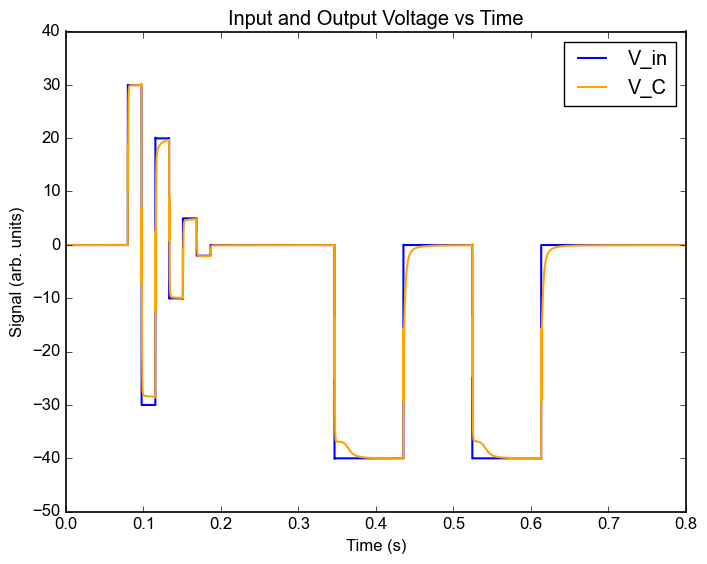

In [93]:
data1 = np.loadtxt("./Data_20262904/20262904005.dat")
data2 = np.loadtxt("./Data_20262904/20262904005.snp")

R1 = 1e6
R2 = 1e5  # Resistance in ohms
Amp = 20

t = data1[:, 0]
V_R = data1[:, 1]
main_trigger = data1[:, 2]
V_in = data1[:, 3]*(-Amp)
second_trigger = data1[:, 4]
I = data1[:, 5]

V_C = V_in - V_R/R2 *(R1 + R2)


plt.plot(t, V_in, label='V_in', lw = 1.5, color = 'blue')
# plt.plot(t, V_R*10, label='V_R', lw = 1.5, color = 'green')
plt.plot(t, V_C, label='V_C', lw = 1.5, color = 'orange')
# plt.plot(t, main_trigger, label='Main Trigger', lw = 1.5, color = 'red')
# plt.plot(t, second_trigger, label='Second Trigger', lw = 1.5, color = 'black')
plt.xlabel('Time (s)')
plt.ylabel('Signal (arb. units)')
# plt.xlim(0.02, 0.22)

plt.title('Input and Output Voltage vs Time')
plt.legend()
plt.show()


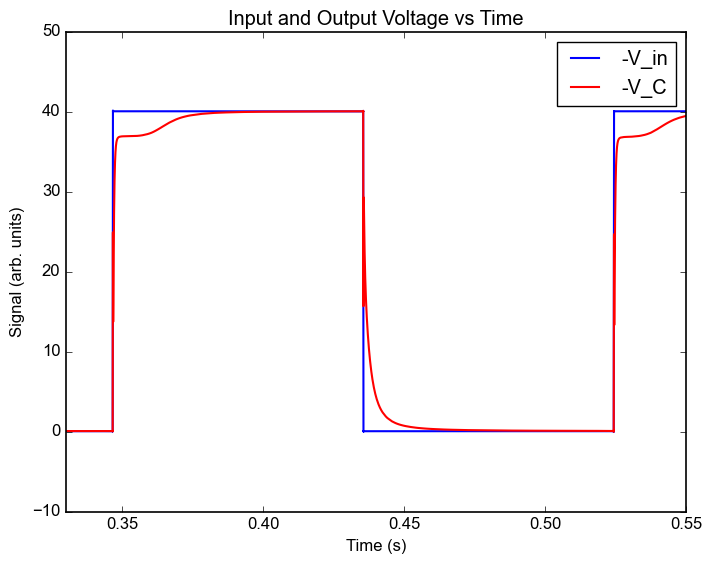

In [94]:
plt.plot(t, -V_in, label='-V_in', lw = 1.5, color = 'blue')
# plt.plot(t, V_R*10, label='V_R', lw = 1.5, color = 'green')
plt.plot(t, -V_C, label='-V_C', lw = 1.5, color = 'red')
# plt.plot(t, main_trigger, label='Main Trigger', lw = 1.5, color = 'red')
# plt.plot(t, second_trigger, label='Second Trigger', lw = 1.5, color = 'black')
plt.xlabel('Time (s)')
plt.ylabel('Signal (arb. units)')
plt.xlim(0.33, 0.55)
plt.ylim(-10, 50)

plt.title('Input and Output Voltage vs Time')
plt.legend()
plt.show()

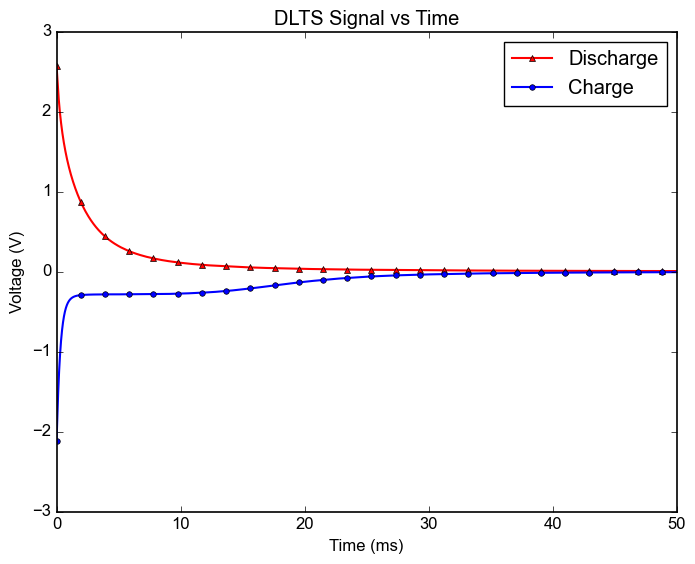

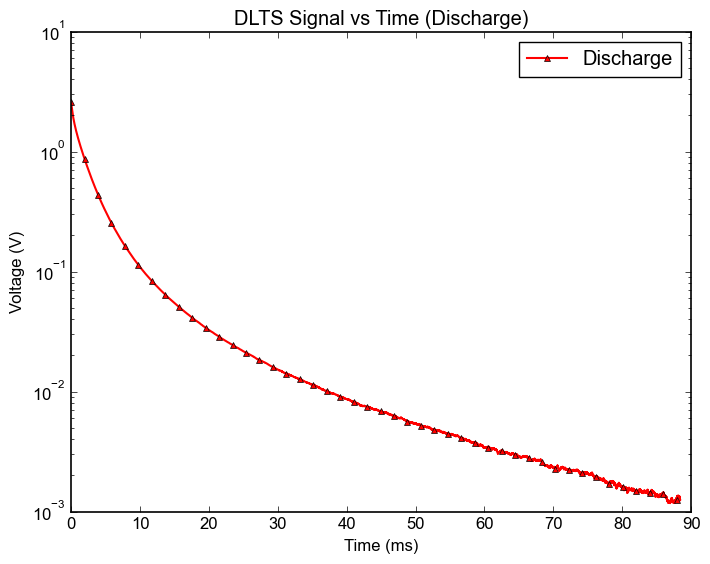

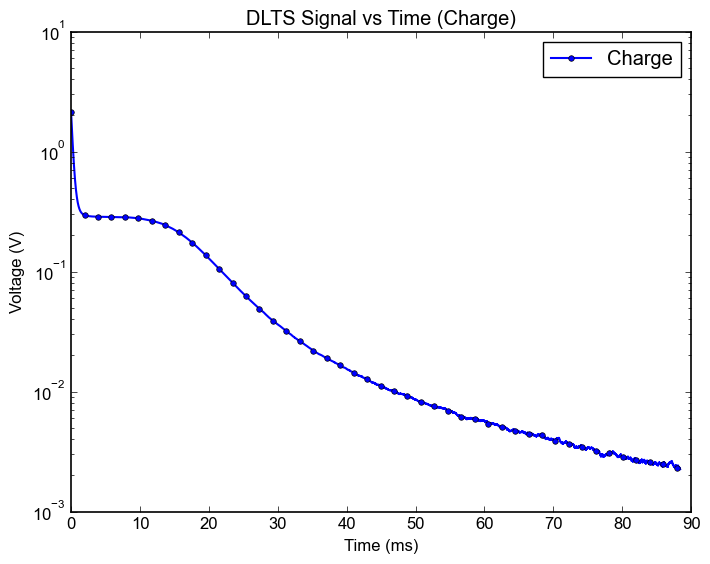

In [95]:
t = data2[:, 0]
V_discharge = data2[:, 2]
V_charge = data2[:, 1]
I_discharge = V_discharge/R2
I_charge = V_charge/R2

plt.plot(t*1e3, V_discharge, label='Discharge', color='red', ls='-', lw = 1.5, marker='^', markersize=4, markevery=200)
plt.plot(t*1e3, V_charge, label='Charge', color='blue', ls='-', lw = 1.5, marker='o', markersize=4, markevery=200)
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (V)')
plt.title('DLTS Signal vs Time')
plt.xlim(0.00, 50)
plt.ylim(-3, 3)
plt.legend(frameon=True, numpoints=1)
plt.show()

plt.semilogy(t*1e3, V_discharge, label='Discharge', color='red', ls='-', lw = 1.5, marker='^', markersize=4, markevery=200)
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (V)')
plt.title('DLTS Signal vs Time (Discharge)')
plt.legend(frameon=True, numpoints=1)
plt.show()

plt.semilogy(t*1e3, -V_charge, label='Charge', color='blue', ls='-', lw = 1.5, marker='o', markersize=4, markevery=200)
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (V)')
plt.title('DLTS Signal vs Time (Charge)')
plt.legend(frameon=True, numpoints=1)
plt.show()


In [96]:
Q_discharge = 0
Q_charge = 0
for i in range(1, len(t)):
    dt = t[i] - t[i-1]
    Q_discharge += I_discharge[i] * dt
    Q_charge += I_charge[i] * dt
    Q_trap = Q_charge + Q_discharge

U0 = 40
C_discharge = np.abs(Q_discharge / U0)
C_charge = np.abs(Q_charge / U0)

print(Q_charge)
print(Q_discharge)
print(Q_trap)

print(C_charge)
print(C_discharge)




-6.806738190851816e-08
6.43783167540296e-08
-3.689065154488564e-09
1.701684547712954e-09
1.6094579188507398e-09
